# Telco Churn Prediction: Detailed EDA + Feature Engineering Notebook

## Objective
Build a robust, reviewer-friendly EDA and feature engineering workflow for churn prediction.

## Scope
- Data understanding and quality checks
- Deep churn-focused EDA
- Feature engineering with lift validation
- Modeling-readiness handoff (no full model training)

## Reproducibility
This notebook is designed to run top-to-bottom with fixed random seed and explicit data quality rules.

In [1]:
# Core imports and plotting setup
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display

SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5)

print("Setup complete. SEED=42")

Setup complete. SEED=42


## 1) Data Loading and Schema Audit

In [2]:
# Load data
df = pd.read_csv("../data/telco_churn.csv")

print("Shape:", df.shape)
display(df.head())

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Basic structure and schema overview
print("Columns:", list(df.columns))
print("\nDtypes:")
display(df.dtypes)

print("\nInfo:")
df.info()

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Dtypes:


customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


Info:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17 

In [4]:
# Data quality snapshot
nulls = df.isnull().sum().sort_values(ascending=False)
nulls = nulls[nulls > 0]
print("Missing columns count:", len(nulls))
display(nulls if len(nulls) > 0 else pd.Series(dtype="int64"))

# Duplicate checks
full_dup_count = df.duplicated().sum()
id_dup_count = df["customerID"].duplicated().sum() if "customerID" in df.columns else np.nan
print(f"Full-row duplicates: {full_dup_count}")
print(f"customerID duplicates: {id_dup_count}")

# Cardinality report
cardinality = df.nunique().sort_values(ascending=False).rename("unique_count")
display(cardinality.to_frame().head(25))

Missing columns count: 0


Series([], dtype: int64)

Full-row duplicates: 0
customerID duplicates: 0


,unique_count
customerID,7043
TotalCharges,6531
MonthlyCharges,1585
tenure,73
PaymentMethod,4
StreamingMovies,3
TechSupport,3
OnlineBackup,3
StreamingTV,3
DeviceProtection,3


## 2) Data Quality Handling (Ported + Improved)
This section preserves the correct logic from the original notebook for `TotalCharges`.

In [5]:
# Convert TotalCharges to numeric and inspect coercion failures
# Do this unconditionally to handle object/string dtypes across pandas versions.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

null_totalcharges = df["TotalCharges"].isna().sum()
print("Null TotalCharges after coercion:", null_totalcharges)

display(df[df["TotalCharges"].isna()][["customerID", "tenure", "MonthlyCharges", "TotalCharges"]].head(20))

Null TotalCharges after coercion: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


In [6]:
# Imputation rule: if customer tenure is 0, TotalCharges should be 0
mask_null_tc = df["TotalCharges"].isna()
mask_zero_tenure = df["tenure"] == 0

print("Null TotalCharges with tenure=0:", (mask_null_tc & mask_zero_tenure).sum())
print("Null TotalCharges with tenure>0:", (mask_null_tc & ~mask_zero_tenure).sum())

# Fill only the expected case directly, then fallback safeguard if any remain
# (for this dataset all null TotalCharges are tenure=0 customers)
df.loc[mask_null_tc & mask_zero_tenure, "TotalCharges"] = 0

if df["TotalCharges"].isna().sum() > 0:
    df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

print("Residual null TotalCharges:", df["TotalCharges"].isna().sum())

Null TotalCharges with tenure=0: 11
Null TotalCharges with tenure>0: 0
Residual null TotalCharges: 0


In [7]:
# Baseline target checks (ported from original and kept)
churn_counts = df["Churn"].value_counts(dropna=False)
churn_ratio = df["Churn"].value_counts(normalize=True, dropna=False).rename("ratio")

print("Churn counts:")
display(churn_counts.to_frame("count"))
print("\nChurn proportions:")
display(churn_ratio.to_frame())

print("Average tenure by churn:")
display(df.groupby("Churn")["tenure"].mean().to_frame("mean_tenure"))

print("Average MonthlyCharges by churn:")
display(df.groupby("Churn")["MonthlyCharges"].mean().to_frame("mean_monthly_charges"))

Churn counts:


,count
Churn,
No,5174
Yes,1869



Churn proportions:


,ratio
Churn,
No,0.73463
Yes,0.26537


Average tenure by churn:


,mean_tenure
Churn,
No,37.569965
Yes,17.979133


Average MonthlyCharges by churn:


,mean_monthly_charges
Churn,
No,61.265124
Yes,74.441332


## 3) Extended EDA (Churn-Focused)
We combine counts with churn rates, then examine numeric distributions and selected interactions.

In [8]:
# Helper for churn-rate by category with counts

def churn_table(data, col, target="Churn"):
    t = pd.crosstab(data[col], data[target])
    t["total"] = t.sum(axis=1)
    t["churn_rate"] = t.get("Yes", 0) / t["total"]
    return t.sort_values("churn_rate", ascending=False)

cat_cols = [
    "gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService", "MultipleLines",
    "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies", "Contract", "PaperlessBilling", "PaymentMethod"
]

for c in ["Contract", "PaymentMethod", "InternetService", "OnlineSecurity", "TechSupport"]:
    print(f"\n=== {c} ===")
    display(churn_table(df, c))


=== Contract ===


Churn,No,Yes,total,churn_rate
Contract,,,,
Month-to-month,2220,1655,3875,0.427097
One year,1307,166,1473,0.112695
Two year,1647,48,1695,0.028319



=== PaymentMethod ===


Churn,No,Yes,total,churn_rate
PaymentMethod,,,,
Electronic check,1294,1071,2365,0.452854
Mailed check,1304,308,1612,0.191067
Bank transfer (automatic),1286,258,1544,0.167098
Credit card (automatic),1290,232,1522,0.152431



=== InternetService ===


Churn,No,Yes,total,churn_rate
InternetService,,,,
Fiber optic,1799,1297,3096,0.418928
DSL,1962,459,2421,0.189591
No,1413,113,1526,0.074050



=== OnlineSecurity ===


Churn,No,Yes,total,churn_rate
OnlineSecurity,,,,
No,2037,1461,3498,0.417667
Yes,1724,295,2019,0.146112
No internet service,1413,113,1526,0.074050



=== TechSupport ===


Churn,No,Yes,total,churn_rate
TechSupport,,,,
No,2027,1446,3473,0.416355
Yes,1734,310,2044,0.151663
No internet service,1413,113,1526,0.074050


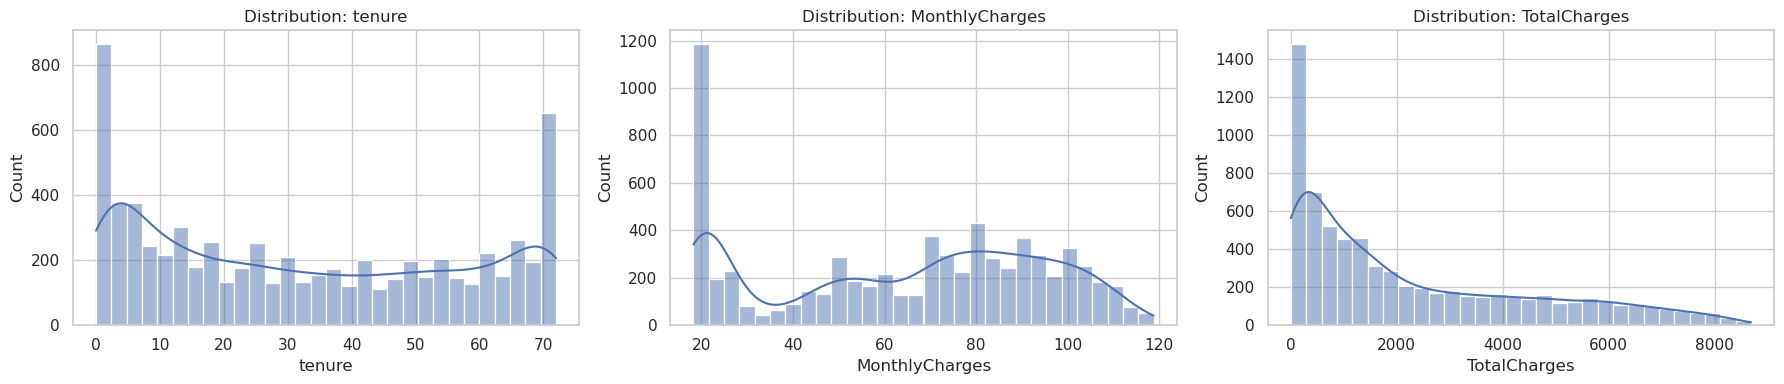

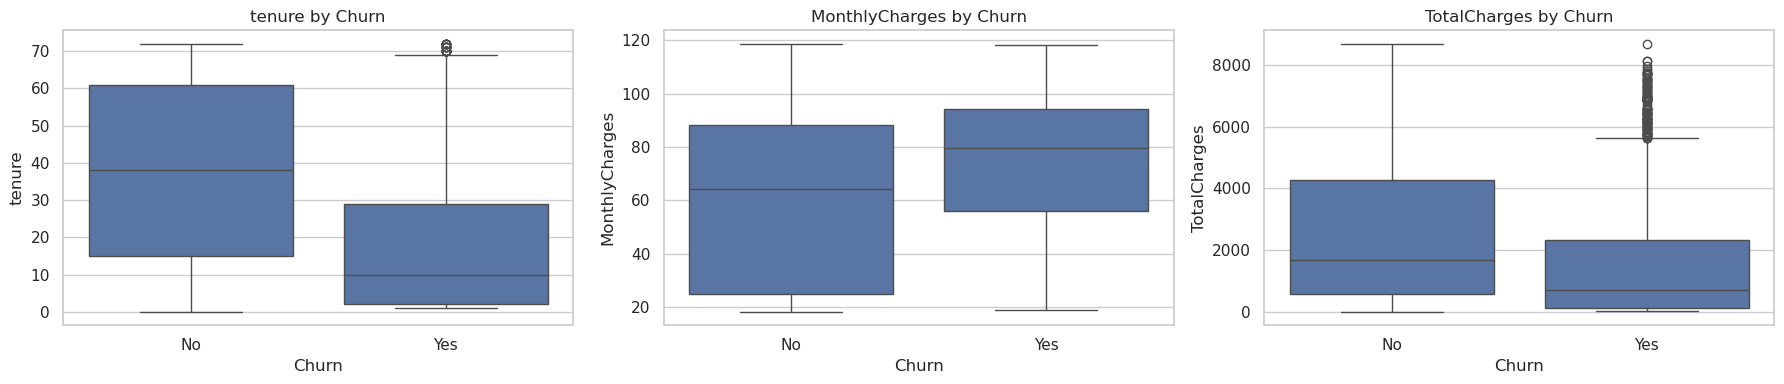

In [9]:
# Univariate distributions for numerical variables
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, c in enumerate(num_cols):
    sns.histplot(df[c], kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f"Distribution: {c}")
plt.tight_layout()
plt.show()

# Boxplots by churn
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, c in enumerate(num_cols):
    sns.boxplot(data=df, x="Churn", y=c, ax=axes[i])
    axes[i].set_title(f"{c} by Churn")
plt.tight_layout()
plt.show()

In [10]:
# Interaction EDA: Contract x InternetService
interaction_1 = (
    df.groupby(["Contract", "InternetService", "Churn"]) 
      .size()
      .rename("count")
      .reset_index()
)

interaction_1_pivot = interaction_1.pivot_table(
    index=["Contract", "InternetService"], columns="Churn", values="count", fill_value=0
)
interaction_1_pivot["total"] = interaction_1_pivot.sum(axis=1)
interaction_1_pivot["churn_rate"] = interaction_1_pivot.get("Yes", 0) / interaction_1_pivot["total"]
display(interaction_1_pivot.sort_values("churn_rate", ascending=False))

Churn                              No     Yes   total  churn_rate
Contract       InternetService                                   
Month-to-month Fiber optic      966.0  1162.0  2128.0    0.546053
               DSL              829.0   394.0  1223.0    0.322159
One year       Fiber optic      435.0   104.0   539.0    0.192950
Month-to-month No               425.0    99.0   524.0    0.188931
One year       DSL              517.0    53.0   570.0    0.092982
Two year       Fiber optic      398.0    31.0   429.0    0.072261
One year       No               355.0     9.0   364.0    0.024725
Two year       DSL              616.0    12.0   628.0    0.019108
               No               633.0     5.0   638.0    0.007837

In [11]:
# Interaction EDA: PaymentMethod x Contract
interaction_2 = (
    df.groupby(["PaymentMethod", "Contract", "Churn"]) 
      .size()
      .rename("count")
      .reset_index()
)

interaction_2_pivot = interaction_2.pivot_table(
    index=["PaymentMethod", "Contract"], columns="Churn", values="count", fill_value=0
)
interaction_2_pivot["total"] = interaction_2_pivot.sum(axis=1)
interaction_2_pivot["churn_rate"] = interaction_2_pivot.get("Yes", 0) / interaction_2_pivot["total"]
display(interaction_2_pivot.sort_values("churn_rate", ascending=False))

,Churn,No,Yes,total,churn_rate
PaymentMethod,Contract,,,,
Electronic check,Month-to-month,856.0,994.0,1850.0,0.537297
Bank transfer (automatic),Month-to-month,388.0,201.0,589.0,0.341256
Credit card (automatic),Month-to-month,365.0,178.0,543.0,0.327808
Mailed check,Month-to-month,611.0,282.0,893.0,0.315789
Electronic check,One year,283.0,64.0,347.0,0.184438
Credit card (automatic),One year,357.0,41.0,398.0,0.103015
Bank transfer (automatic),One year,353.0,38.0,391.0,0.097187
Electronic check,Two year,155.0,13.0,168.0,0.077381
Mailed check,One year,314.0,23.0,337.0,0.068249


**EDA business notes**
- Month-to-month and electronic check segments should be treated as high-risk cohorts.
- Short tenure and higher monthly charges remain strong churn correlates.
- Interaction views help prioritize retention campaigns by customer sub-segment, not only single variables.

## 4) Feature Engineering (Ported + Extended)

In [12]:
# Existing useful features from the original notebook

df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=["new", "mid", "loyal", "very_loyal"]
)

df["is_monthly"] = (df["Contract"] == "Month-to-month").astype(int)
df["is_electronic"] = (df["PaymentMethod"] == "Electronic check").astype(int)

services = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"
]
df["num_services"] = df[services].apply(lambda x: (x == "Yes").sum(), axis=1)

df["charge_group"] = pd.cut(
    df["MonthlyCharges"],
    bins=[0, 50, 80, 120],
    labels=["low", "mid", "high"],
    include_lowest=True
)

print("Ported engineered features added.")

Ported engineered features added.


In [13]:
# Extended engineered features

df["avg_monthly_spend_proxy"] = df["TotalCharges"] / np.where(df["tenure"] > 0, df["tenure"], 1)

df["has_security_bundle"] = ((df["OnlineSecurity"] == "Yes") & (df["TechSupport"] == "Yes")).astype(int)
df["lacks_protection_bundle"] = ((df["OnlineSecurity"] != "Yes") & (df["TechSupport"] != "Yes")).astype(int)

df["monthly_and_electronic"] = ((df["Contract"] == "Month-to-month") & (df["PaymentMethod"] == "Electronic check")).astype(int)

df["streaming_heavy"] = ((df["StreamingTV"] == "Yes") & (df["StreamingMovies"] == "Yes")).astype(int)

print("Extended features added.")

Extended features added.


In [14]:
# Feature impact validation: churn rate, sample size, and lift vs global churn
GLOBAL_CHURN = (df["Churn"] == "Yes").mean()


def feature_lift_table(data, feature, target="Churn"):
    grouped = data.groupby(feature)[target].agg(
        sample_size="count",
        churn_rate=lambda x: (x == "Yes").mean()
    )
    grouped["lift_vs_global"] = grouped["churn_rate"] / GLOBAL_CHURN
    return grouped.sort_values("churn_rate", ascending=False)

features_to_validate = [
    "tenure_group", "is_monthly", "is_electronic", "num_services", "charge_group",
    "avg_monthly_spend_proxy", "has_security_bundle", "lacks_protection_bundle",
    "monthly_and_electronic", "streaming_heavy"
]

print(f"Global churn rate: {GLOBAL_CHURN:.4f}")

for feat in features_to_validate:
    print(f"\n=== Feature validation: {feat} ===")
    if feat == "avg_monthly_spend_proxy":
        # Bin continuous proxy for clearer lift interpretation
        temp_col = "avg_monthly_spend_proxy_bin"
        data_temp = df.copy()
        data_temp[temp_col] = pd.qcut(data_temp[feat], q=5, duplicates="drop")
        display(feature_lift_table(data_temp, temp_col))
    else:
        display(feature_lift_table(df, feat))

Global churn rate: 0.2654

=== Feature validation: tenure_group ===


,sample_size,churn_rate,lift_vs_global
tenure_group,,,
new,2186,0.474382,1.787627
mid,1024,0.287109,1.081922
loyal,1594,0.203890,0.768322
very_loyal,2239,0.095132,0.358487



=== Feature validation: is_monthly ===


,sample_size,churn_rate,lift_vs_global
is_monthly,,,
1,3875,0.427097,1.609440
0,3168,0.067551,0.254552



=== Feature validation: is_electronic ===


...

,sample_size,churn_rate,lift_vs_global
lacks_protection_bundle,,,
1,4079,0.334151,1.259188
0,2964,0.170715,0.643311



=== Feature validation: monthly_and_electronic ===


,sample_size,churn_rate,lift_vs_global
monthly_and_electronic,,,
1,1850,0.537297,2.024711
0,5193,0.168496,0.634948



=== Feature validation: streaming_heavy ===


,sample_size,churn_rate,lift_vs_global
streaming_heavy,,,
1,1940,0.29433,1.109131
0,5103,0.25436,0.958512


## 7) Feature Contract (Single Source of Truth)
This section freezes feature roles, missing-value policy, encoding intent, and scoring-time availability.

In [15]:
# Build feature contract table
feature_contract_rows = []

# Identify canonical sets
id_features = ["customerID"] if "customerID" in df.columns else []
target_feature = "Churn"

for c in df.columns:
    if c == target_feature:
        role = "target"
        encoding_intent = "label_encode_yes_no"
        available_at_scoring_time = True
    elif c in id_features:
        role = "id"
        encoding_intent = "drop_before_model"
        available_at_scoring_time = True
    else:
        role = "input"
        if str(df[c].dtype) in ["int64", "float64"]:
            encoding_intent = "numeric_passthrough_or_scale_for_linear"
        elif str(df[c].dtype) == "category":
            encoding_intent = "one_hot_or_target_encode"
        else:
            encoding_intent = "one_hot_or_target_encode"
        available_at_scoring_time = True

    missing_policy = "none_detected"
    if df[c].isna().sum() > 0:
        if c == "TotalCharges":
            missing_policy = "coerce_to_numeric_then_fill_0_if_tenure0_else_median"
        else:
            missing_policy = "impute_strategy_to_define"

    feature_contract_rows.append({
        "feature_name": c,
        "role": role,
        "dtype_expected": str(df[c].dtype),
        "missing_policy": missing_policy,
        "encoding_intent": encoding_intent,
        "available_at_scoring_time": available_at_scoring_time,
    })

feature_contract = pd.DataFrame(feature_contract_rows)
display(feature_contract)

print("Target definition frozen: Churn positive class = 'Yes'")

,feature_name,role,dtype_expected,missing_policy,encoding_intent,available_at_scoring_time
0,customerID,id,str,none_detected,drop_before_model,True
1,gender,input,str,none_detected,one_hot_or_target_encode,True
2,SeniorCitizen,input,int64,none_detected,numeric_passthrough_or_scale_for_linear,True
3,Partner,input,str,none_detected,one_hot_or_target_encode,True
4,Dependents,input,str,none_detected,one_hot_or_target_encode,True
5,tenure,input,int64,none_detected,numeric_passthrough_or_scale_for_linear,True
6,PhoneService,input,str,none_detected,one_hot_or_target_encode,True
7,MultipleLines,input,str,none_detected,one_hot_or_target_encode,True
8,InternetService,input,str,none_detected,one_hot_or_target_encode,True
9,OnlineSecurity,input,str,none_detected,one_hot_or_target_encode,True


Target definition frozen: Churn positive class = 'Yes'


In [16]:
# Verify identifier treatment explicitly
if "customerID" in feature_contract["feature_name"].values:
    display(feature_contract[feature_contract["feature_name"] == "customerID"])
    print("customerID is marked as id and excluded from model input.")
else:
    print("customerID is not present in current df (expected if already dropped in a separate frame).")

,feature_name,role,dtype_expected,missing_policy,encoding_intent,available_at_scoring_time
0,customerID,id,str,none_detected,drop_before_model,True


customerID is marked as id and excluded from model input.


## 8) Preprocessing-Driven Diagnostics

In [17]:
# Category anomaly checks (empty / whitespace)
# Include pandas string/category dtypes for cross-version robustness.
obj_cols = df.select_dtypes(include=["object", "string", "category"]).columns.tolist()
anomaly_rows = []

for c in obj_cols:
    s = df[c].astype(str)
    empty_count = (s == "").sum()
    whitespace_only_count = (s.str.strip() == "").sum() - empty_count
    anomaly_rows.append({
        "feature": c,
        "empty_count": int(empty_count),
        "whitespace_only_count": int(max(whitespace_only_count, 0))
    })

if len(anomaly_rows) == 0:
    category_anomalies = pd.DataFrame(columns=["feature", "empty_count", "whitespace_only_count"])
else:
    category_anomalies = pd.DataFrame(anomaly_rows).sort_values(["empty_count", "whitespace_only_count"], ascending=False)

display(category_anomalies)

,feature,empty_count,whitespace_only_count
0,customerID,0,0
1,gender,0,0
2,Partner,0,0
3,Dependents,0,0
4,PhoneService,0,0
5,MultipleLines,0,0
6,InternetService,0,0
7,OnlineSecurity,0,0
8,OnlineBackup,0,0
9,DeviceProtection,0,0


In [18]:
# Numeric sanity checks
sanity = {
    "tenure_negative_count": int((df["tenure"] < 0).sum()),
    "monthly_charges_negative_count": int((df["MonthlyCharges"] < 0).sum()),
    "total_charges_negative_count": int((df["TotalCharges"] < 0).sum()),
}

sanity_df = pd.DataFrame.from_dict(sanity, orient="index", columns=["count"])
display(sanity_df)

,count
tenure_negative_count,0
monthly_charges_negative_count,0
total_charges_negative_count,0


In [19]:
# Rare-category analysis with churn-rate stability

def rare_category_report(data, col, target="Churn", rare_threshold=0.01):
    t = data.groupby(col)[target].agg(
        sample_size="count",
        churn_rate=lambda x: (x == "Yes").mean()
    ).reset_index()
    t["share"] = t["sample_size"] / len(data)
    t["is_rare"] = t["share"] < rare_threshold
    return t.sort_values(["is_rare", "share", "churn_rate"], ascending=[False, True, False])

rare_reports = {}
for c in obj_cols:
    if c == "Churn":
        continue
    rare_reports[c] = rare_category_report(df, c)

for c in ["PaymentMethod", "InternetService", "Contract", "MultipleLines"]:
    if c in rare_reports:
        print(f"\n=== Rare-category profile: {c} ===")
        display(rare_reports[c])


=== Rare-category profile: PaymentMethod ===


,PaymentMethod,sample_size,churn_rate,share,is_rare
1,Credit card (automatic),1522,0.152431,0.216101,False
0,Bank transfer (automatic),1544,0.167098,0.219225,False
3,Mailed check,1612,0.191067,0.228880,False
2,Electronic check,2365,0.452854,0.335794,False



=== Rare-category profile: InternetService ===


,InternetService,sample_size,churn_rate,share,is_rare
2,No,1526,0.074050,0.216669,False
0,DSL,2421,0.189591,0.343746,False
1,Fiber optic,3096,0.418928,0.439585,False



=== Rare-category profile: Contract ===


,Contract,sample_size,churn_rate,share,is_rare
1,One year,1473,0.112695,0.209144,False
2,Two year,1695,0.028319,0.240664,False
0,Month-to-month,3875,0.427097,0.550192,False



=== Rare-category profile: MultipleLines ===


,MultipleLines,sample_size,churn_rate,share,is_rare
1,No phone service,682,0.249267,0.096834,False
2,Yes,2971,0.286099,0.421837,False
0,No,3390,0.250442,0.481329,False


In [20]:
# Numeric outlier diagnostics (IQR + percentiles)
num_cols_diag = [c for c in df.columns if str(df[c].dtype) in ["int64", "float64"] and c not in ["is_monthly", "is_electronic", "num_services", "has_security_bundle", "lacks_protection_bundle", "monthly_and_electronic", "streaming_heavy"]]

outlier_rows = []
for c in num_cols_diag:
    q1 = df[c].quantile(0.25)
    q3 = df[c].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = ((df[c] < lower) | (df[c] > upper)).sum()

    outlier_rows.append({
        "feature": c,
        "q01": df[c].quantile(0.01),
        "q25": q1,
        "q50": df[c].quantile(0.50),
        "q75": q3,
        "q99": df[c].quantile(0.99),
        "iqr_outlier_count": int(outliers),
        "iqr_outlier_ratio": float(outliers / len(df))
    })

outlier_report = pd.DataFrame(outlier_rows).sort_values("iqr_outlier_ratio", ascending=False)
display(outlier_report)

,feature,q01,q25,q50,q75,q99,iqr_outlier_count,iqr_outlier_ratio
0,SeniorCitizen,0.00000,0.000,0.00,0.000000,1.000000,1142,0.162147
1,tenure,1.00000,9.000,29.00,55.000000,72.000000,0,0.000000
2,MonthlyCharges,19.20000,35.500,70.35,89.850000,114.729000,0,0.000000
3,TotalCharges,19.75000,398.550,1394.55,3786.600000,8039.256000,0,0.000000
4,avg_monthly_spend_proxy,17.38985,35.649,70.30,90.174158,115.020704,0,0.000000


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,is_monthly,is_electronic,num_services,avg_monthly_spend_proxy,has_security_bundle,lacks_protection_bundle,monthly_and_electronic,streaming_heavy
SeniorCitizen,1.000,0.017,0.220,0.103,0.138,0.172,0.067,0.218,-0.059,0.048,0.186,0.096
tenure,0.017,1.000,0.248,0.826,-0.646,-0.208,0.494,0.249,0.335,-0.352,-0.350,0.313
MonthlyCharges,0.220,0.248,1.000,0.651,0.060,0.272,0.725,0.994,0.239,-0.407,0.203,0.584
TotalCharges,0.103,0.826,0.651,1.000,-0.444,-0.059,0.745,0.651,0.397,-0.482,-0.213,0.538
is_monthly,0.138,-0.646,0.060,-0.444,1.000,0.332,-0.291,0.061,-0.314,0.257,0.540,-0.163
is_electronic,0.172,-0.208,0.272,-0.059,0.332,1.000,0.018,0.272,-0.157,0.093,0.839,0.111
num_services,0.067,0.494,0.725,0.745,-0.291,0.018,1.000,0.720,0.568,-0.695,-0.101,0.679
avg_monthly_spend_proxy,0.218,0.249,0.994,0.651,0.061,0.272,0.720,1.000,0.238,-0.404,0.203,0.581
has_security_bundle,-0.059,0.335,0.239,0.397,-0.314,-0.157,0.568,0.238,1.000,-0.504,-0.203,0.181
lacks_protection_bundle,0.048,-0.352,-0.407,-0.482,0.257,0.093,-0.695,-0.404,-0.504,1.000,0.176,-0.253


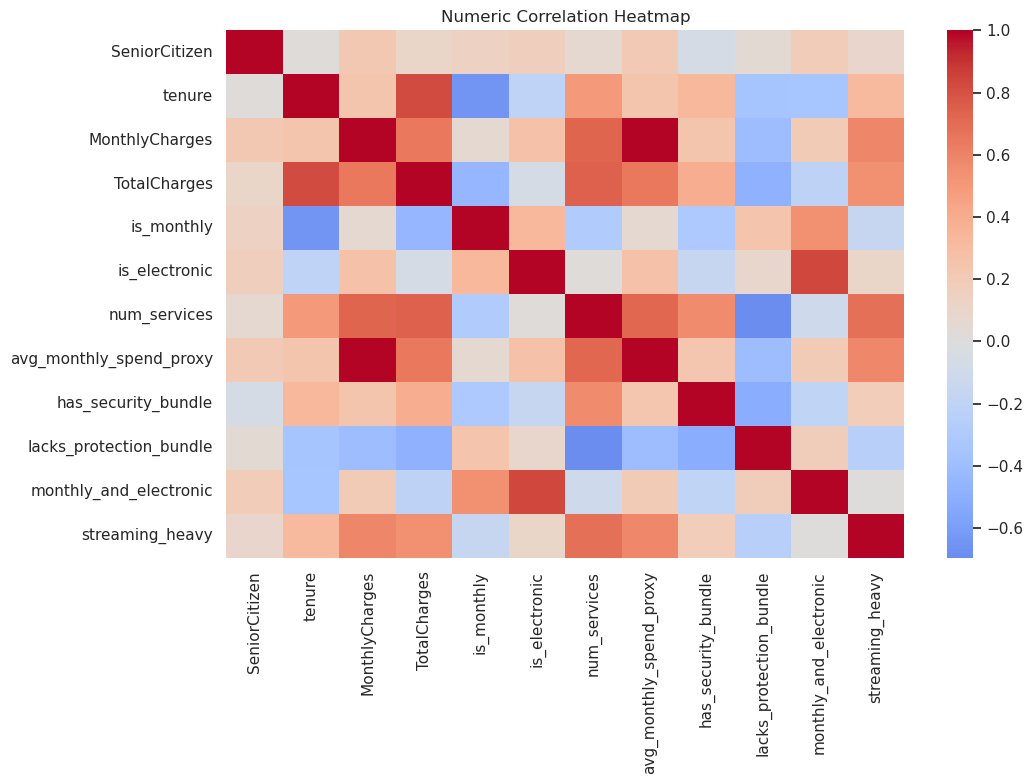

In [21]:
# Redundancy diagnostics: numeric correlation matrix
corr_cols = [c for c in df.columns if str(df[c].dtype) in ["int64", "float64"]]
corr_matrix = df[corr_cols].corr(numeric_only=True)

display(corr_matrix.round(3))

plt.figure(figsize=(11, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Numeric Correlation Heatmap")
plt.tight_layout()
plt.show()

**Redundancy notes (for later model-family decisions)**
- `is_monthly` is a derived proxy of `Contract`.
- `is_electronic` is a derived proxy of `PaymentMethod`.
- `charge_group` is a binned proxy of `MonthlyCharges`.
- For linear models, keep either parent or child representations to reduce collinearity risk.

## 9) Hardened Feature Engineering Extensions

In [22]:
# Low-leakage monotonic-friendly transforms

# Skew-friendly transforms
df["monthly_charges_log1p"] = np.log1p(df["MonthlyCharges"])
df["total_charges_log1p"] = np.log1p(df["TotalCharges"])

# Stability-aware tenure bins with persisted edges
tenure_bin_edges = [-1, 6, 12, 24, 48, 72]
df["tenure_group_v2"] = pd.cut(
    df["tenure"],
    bins=tenure_bin_edges,
    labels=["0_6", "7_12", "13_24", "25_48", "49_72"]
)

# Ratio-style support burden proxy
df["services_per_tenure_month"] = df["num_services"] / np.where(df["tenure"] > 0, df["tenure"], 1)

print("Hardened FE extensions created.")
print("Persisted tenure_bin_edges:", tenure_bin_edges)

Hardened FE extensions created.
Persisted tenure_bin_edges: [-1, 6, 12, 24, 48, 72]


In [23]:
# Rare-category consolidation helper (for later pipeline reuse)
def collapse_rare_levels(data, col, min_share=0.02, other_label="Other"):
    shares = data[col].value_counts(normalize=True)
    keep_levels = shares[shares >= min_share].index
    return data[col].where(data[col].isin(keep_levels), other_label)

# Example consolidated variables
for c in ["PaymentMethod", "MultipleLines"]:
    new_col = f"{c}_grp"
    df[new_col] = collapse_rare_levels(df, c, min_share=0.02)

print("Created rare-level consolidated variants: PaymentMethod_grp, MultipleLines_grp")

Created rare-level consolidated variants: PaymentMethod_grp, MultipleLines_grp


In [24]:
# Lift validation for newly engineered features
new_features_to_validate = [
    "tenure_group_v2", "monthly_charges_log1p", "total_charges_log1p",
    "services_per_tenure_month", "PaymentMethod_grp", "MultipleLines_grp"
]

for feat in new_features_to_validate:
    print(f"\n=== New feature validation: {feat} ===")
    if feat in ["monthly_charges_log1p", "total_charges_log1p", "services_per_tenure_month"]:
        temp_col = f"{feat}_bin"
        temp_df = df.copy()
        temp_df[temp_col] = pd.qcut(temp_df[feat], q=5, duplicates="drop")
        display(feature_lift_table(temp_df, temp_col))
    else:
        display(feature_lift_table(df, feat))


=== New feature validation: tenure_group_v2 ===


,sample_size,churn_rate,lift_vs_global
tenure_group_v2,,,
0_6,1481,0.529372,1.994846
7_12,705,0.358865,1.352321
13_24,1024,0.287109,1.081922
25_48,1594,0.203890,0.768322
49_72,2239,0.095132,0.358487



=== New feature validation: monthly_charges_log1p ===


,sample_size,churn_rate,lift_vs_global
monthly_charges_log1p_bin,,,
"(4.383, 4.557]",1407,0.361052,1.360561
"(4.557, 4.785]",1408,0.328125,1.236482
"(4.092, 4.383]",1411,0.297661,1.121684
"(3.26, 4.092]",1397,0.249821,0.941407
"(2.9570000000000003, 3.26]",1420,0.091549,0.344988



=== New feature validation: total_charges_log1p ===


...

,sample_size,churn_rate,lift_vs_global
services_per_tenure_month_bin,,,
"(0.136, 5.0]",1407,0.496091,1.869432
"(0.0755, 0.136]",1406,0.237553,0.895178
"(-0.001, 0.0448]",2823,0.210414,0.792910
"(0.0448, 0.0755]",1407,0.172708,0.650820



=== New feature validation: PaymentMethod_grp ===


,sample_size,churn_rate,lift_vs_global
PaymentMethod_grp,,,
Electronic check,2365,0.452854,1.706502
Mailed check,1612,0.191067,0.720003
Bank transfer (automatic),1544,0.167098,0.629681
Credit card (automatic),1522,0.152431,0.574410



=== New feature validation: MultipleLines_grp ===


,sample_size,churn_rate,lift_vs_global
MultipleLines_grp,,,
Yes,2971,0.286099,1.078114
No,3390,0.250442,0.943749
No phone service,682,0.249267,0.939319


## 10) Preprocessing Blueprint for SoTA Benchmarking (No Fitting)

In [25]:
# Model-family-ready feature groups (design only)
all_binary_candidates = [
    "SeniorCitizen", "is_monthly", "is_electronic", "has_security_bundle",
    "lacks_protection_bundle", "monthly_and_electronic", "streaming_heavy"
]
binary_features = [c for c in all_binary_candidates if c in df.columns]

all_numeric_candidates = [
    "tenure", "MonthlyCharges", "TotalCharges", "num_services",
    "avg_monthly_spend_proxy", "monthly_charges_log1p", "total_charges_log1p",
    "services_per_tenure_month"
]
numeric_features_blueprint = [c for c in all_numeric_candidates if c in df.columns]

categorical_features_blueprint = [
    c for c in df.columns
    if (df[c].dtype == "object" or str(df[c].dtype) == "category") and c not in ["Churn", "customerID"]
]

preprocessing_blueprint = {
    "target": "Churn",
    "positive_class": "Yes",
    "id_columns": [c for c in ["customerID"] if c in df.columns],
    "numeric_features": numeric_features_blueprint,
    "binary_features": binary_features,
    "categorical_features": categorical_features_blueprint,
    "imputation_rules": {
        "numeric": "median_or_domain_rule",
        "categorical": "most_frequent_or_explicit_unknown",
        "special_case_TotalCharges": "fill_0_if_tenure0_else_median"
    },
    "encoder_candidates": {
        "linear_or_kernel": "one_hot_for_categoricals + scale_numeric",
        "tree_boosting": "ordinal_or_one_hot_categoricals + optional_no_scaling",
        "tabular_deep_learning": "embedding_or_target_encoding_style_inputs"
    }
}

display(pd.DataFrame({k: [v] for k, v in preprocessing_blueprint.items() if k not in ["numeric_features", "binary_features", "categorical_features"]}))
print("\nNumeric features:", preprocessing_blueprint["numeric_features"])
print("Binary features:", preprocessing_blueprint["binary_features"])
print("Categorical features:", preprocessing_blueprint["categorical_features"])

,target,positive_class,id_columns,imputation_rules,encoder_candidates
0,Churn,Yes,[customerID],"{'numeric': 'median_or_domain_rule', 'categori...",{'linear_or_kernel': 'one_hot_for_categoricals...



Numeric features: ['tenure', 'MonthlyCharges', 'TotalCharges', 'num_services', 'avg_monthly_spend_proxy', 'monthly_charges_log1p', 'total_charges_log1p', 'services_per_tenure_month']
Binary features: ['SeniorCitizen', 'is_monthly', 'is_electronic', 'has_security_bundle', 'lacks_protection_bundle', 'monthly_and_electronic', 'streaming_heavy']
Categorical features: ['tenure_group', 'charge_group', 'tenure_group_v2']


In [26]:
# Class-imbalance preparation options to compare later (not applied now)
class_ratio = (df["Churn"] == "Yes").mean()
imbalance_plan = pd.DataFrame(
    [
        {"option": "class_weight_balanced", "apply_stage": "model_fit", "note": "baseline for linear/tree models"},
        {"option": "random_undersampling", "apply_stage": "train_only", "note": "reduce majority dominance"},
        {"option": "SMOTE_or_SMOTEENN", "apply_stage": "train_only", "note": "synthetic minority enrichment"},
        {"option": "focal_or_cost_sensitive_loss", "apply_stage": "model_fit", "note": "penalize false negatives more"},
    ]
)

print(f"Observed churn prevalence: {class_ratio:.4f}")
display(imbalance_plan)

Observed churn prevalence: 0.2654


,option,apply_stage,note
0,class_weight_balanced,model_fit,baseline for linear/tree models
1,random_undersampling,train_only,reduce majority dominance
2,SMOTE_or_SMOTEENN,train_only,synthetic minority enrichment
3,focal_or_cost_sensitive_loss,model_fit,penalize false negatives more


## 11) Exportable Handoff Artifacts + Ready-for-Training Checklist

In [27]:
# Optional export of processed data + metadata
import json

EXPORT_HANDOFF = False
handoff_data_path = "telco_processed_eda_fe_v2.csv"
handoff_meta_path = "telco_preprocessing_blueprint_v2.json"

# Build model_df_v2 as final handoff frame
model_df_v2 = df.drop(columns=["customerID"], errors="ignore").copy()

metadata_payload = {
    "target": preprocessing_blueprint["target"],
    "positive_class": preprocessing_blueprint["positive_class"],
    "id_columns": preprocessing_blueprint["id_columns"],
    "numeric_features": preprocessing_blueprint["numeric_features"],
    "binary_features": preprocessing_blueprint["binary_features"],
    "categorical_features": preprocessing_blueprint["categorical_features"],
    "imputation_rules": preprocessing_blueprint["imputation_rules"],
    "encoder_candidates": preprocessing_blueprint["encoder_candidates"],
    "tenure_bin_edges": tenure_bin_edges,
}

if EXPORT_HANDOFF:
    model_df_v2.to_csv(handoff_data_path, index=False)
    with open(handoff_meta_path, "w", encoding="utf-8") as f:
        json.dump(metadata_payload, f, indent=2)
    print(f"Saved data: {handoff_data_path}")
    print(f"Saved metadata: {handoff_meta_path}")
else:
    print("Export skipped. Set EXPORT_HANDOFF=True to write handoff files.")

print("Handoff dataframe shape:", model_df_v2.shape)
print("Metadata keys:", list(metadata_payload.keys()))

Export skipped. Set EXPORT_HANDOFF=True to write handoff files.
Handoff dataframe shape: (7043, 36)
Metadata keys: ['target', 'positive_class', 'id_columns', 'numeric_features', 'binary_features', 'categorical_features', 'imputation_rules', 'encoder_candidates', 'tenure_bin_edges']


In [28]:
# Ready-for-training checklist
checklist = {
    "target_definition_frozen": True,
    "id_column_documented": "customerID" in feature_contract["feature_name"].values,
    "feature_contract_available": "feature_contract" in globals(),
    "no_missing_values_in_model_df_v2": int(model_df_v2.isna().sum().sum()) == 0,
    "duplicates_checked": True,
    "rare_category_analysis_done": "rare_reports" in globals(),
    "outlier_report_done": "outlier_report" in globals(),
    "lift_validation_done": "GLOBAL_CHURN" in globals(),
    "preprocessing_blueprint_defined": "preprocessing_blueprint" in globals(),
    "training_not_started": True,
}

checklist_df = pd.DataFrame.from_dict(checklist, orient="index", columns=["status"])
display(checklist_df)

all_ready = checklist_df["status"].all()
print("\nReady for next phase (train/val protocol):", all_ready)

,status
target_definition_frozen,True
id_column_documented,True
feature_contract_available,True
no_missing_values_in_model_df_v2,True
duplicates_checked,True
rare_category_analysis_done,True
outlier_report_done,True
lift_validation_done,True
preprocessing_blueprint_defined,True
training_not_started,True



Ready for next phase (train/val protocol): True


In [29]:
# Final QA summary block with pass/fail flags
qa_flags = {
    "no_negative_tenure": int((df["tenure"] < 0).sum()) == 0,
    "no_negative_monthly_charges": int((df["MonthlyCharges"] < 0).sum()) == 0,
    "no_negative_total_charges": int((df["TotalCharges"] < 0).sum()) == 0,
    "target_has_two_classes": df["Churn"].nunique() == 2,
    "model_df_v2_has_rows": len(model_df_v2) > 0,
}

qa_flags_df = pd.DataFrame.from_dict(qa_flags, orient="index", columns=["pass"])
display(qa_flags_df)
print("Overall QA pass:", qa_flags_df["pass"].all())

,pass
no_negative_tenure,True
no_negative_monthly_charges,True
no_negative_total_charges,True
target_has_two_classes,True
model_df_v2_has_rows,True


Overall QA pass: True


## 5) Modeling-Readiness Prep (EDA + FE Handoff)

In [30]:
# Remove identifier and define feature groups for next-stage modeling
model_df = df.drop(columns=["customerID"], errors="ignore").copy()

numeric_features = [
    "tenure", "MonthlyCharges", "TotalCharges", "num_services", "avg_monthly_spend_proxy"
]

binary_engineered_features = [
    "is_monthly", "is_electronic", "has_security_bundle",
    "lacks_protection_bundle", "monthly_and_electronic", "streaming_heavy"
]

categorical_features = [
    c for c in model_df.columns
    if model_df[c].dtype == "object" or str(model_df[c].dtype) == "category"
]
categorical_features = [c for c in categorical_features if c != "Churn"]

print("Model dataframe shape:", model_df.shape)
print("Numeric features:", numeric_features)
print("Binary engineered features:", binary_engineered_features)
print("Categorical features count:", len(categorical_features))

Model dataframe shape: (7043, 36)
Numeric features: ['tenure', 'MonthlyCharges', 'TotalCharges', 'num_services', 'avg_monthly_spend_proxy']
Binary engineered features: ['is_monthly', 'is_electronic', 'has_security_bundle', 'lacks_protection_bundle', 'monthly_and_electronic', 'streaming_heavy']
Categorical features count: 3


**Encoding/scaling guidance for the next notebook**
- Use train/test split before fitting any encoder/scaler.
- Prefer one-hot encoding for nominal categorical variables.
- For linear models, standardize numeric features and monitor multicollinearity.
- For tree-based models, scaling is optional; keep interpretable engineered flags.

## 6) Final QA, Export, and Executive Notes

In [31]:
# End-of-notebook quality checklist
qa = {
    "rows": len(model_df),
    "columns": model_df.shape[1],
    "null_cells": int(model_df.isnull().sum().sum()),
    "full_row_duplicates": int(model_df.duplicated().sum()),
    "target_unique_values": int(model_df["Churn"].nunique()) if "Churn" in model_df.columns else np.nan,
}

qa_df = pd.DataFrame.from_dict(qa, orient="index", columns=["value"])
display(qa_df)

print("\nDtype snapshot:")
display(model_df.dtypes.value_counts().rename("count").to_frame())

,value
rows,7043
columns,36
null_cells,0
full_row_duplicates,22
target_unique_values,2



Dtype snapshot:


,count
str,18
int64,9
float64,6
category,1
category,1
category,1


In [32]:
# Optional processed-data export for downstream modeling
EXPORT_PROCESSED = False
export_path = "telco_processed_eda_fe.csv"

if EXPORT_PROCESSED:
    model_df.to_csv(export_path, index=False)
    print(f"Processed dataset saved to: {export_path}")
else:
    print("Export skipped. Set EXPORT_PROCESSED=True to save processed data.")

Export skipped. Set EXPORT_PROCESSED=True to save processed data.


### Key churn insights
- Month-to-month contract customers have materially higher churn risk.
- Electronic check cohorts are consistently riskier than automatic payment cohorts.
- Lower tenure remains one of the strongest churn signals.
- Customers without support/security bundles trend to higher churn.

### Next steps
1. Build split-safe preprocessing pipeline (train-fit, test-transform).
2. Train baseline models (logistic regression and tree-based model).
3. Evaluate with ROC-AUC, PR-AUC, calibration, and threshold-based business metrics.
4. Convert top drivers into retention strategy experiments.

## 12) Split-Safe Training Protocol + SoTA Model Benchmark

This section keeps the original EDA/feature engineering intact and adds a strict train-fit/test-transform protocol.

- No test leakage: preprocessing is fitted only on training folds.
- Reproducible split and metrics across models.
- Evaluation includes ROC-AUC, PR-AUC, calibration, and business-threshold outcomes.

In [33]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    precision_recall_curve,
    roc_curve,
    confusion_matrix,
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [34]:
available_external_models = {}

try:
    from xgboost import XGBClassifier
    available_external_models['xgboost'] = True
except Exception:
    available_external_models['xgboost'] = False

try:
    from lightgbm import LGBMClassifier
    available_external_models['lightgbm'] = True
except Exception:
    available_external_models['lightgbm'] = False

try:
    from catboost import CatBoostClassifier
    available_external_models['catboost'] = True
except Exception:
    available_external_models['catboost'] = False

print('External model availability:', available_external_models)

External model availability: {'xgboost': False, 'lightgbm': False, 'catboost': False}


## 13) Build Train/Test Data and Feature Lists

In [35]:
if 'model_df' not in globals():
    raise ValueError('model_df not found. Run previous EDA/feature engineering cells first.')
if 'Churn' not in model_df.columns:
    raise ValueError("Target column 'Churn' is missing in model_df.")

modeling_df = model_df.copy()
y = modeling_df['Churn'].map({'Yes': 1, 'No': 0})
if y.isna().any():
    raise ValueError("Unexpected target labels. Expected {'Yes','No'}.")

y = y.astype(int)
X = modeling_df.drop(columns=['Churn'])

# Robust dtype split: treat only numeric/bool as numeric, everything else as categorical.
# This prevents pandas 'string' dtype columns (e.g., gender) from entering median imputation.
numeric_cols = X.select_dtypes(include=[np.number, 'bool']).columns.tolist()
categorical_cols = [c for c in X.columns if c not in numeric_cols]

print('X shape:', X.shape)
print('Target positive rate (churn):', y.mean())
print('Numeric columns:', len(numeric_cols))
print('Categorical columns:', len(categorical_cols))

X shape: (7043, 35)
Target positive rate (churn): 0.2653698707936959
Numeric columns: 15
Categorical columns: 20


In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print('Train shape:', X_train.shape)
print('Test shape :', X_test.shape)
print('Train churn rate:', y_train.mean())
print('Test churn rate :', y_test.mean())

Train shape: (5634, 35)
Test shape : (1409, 35)
Train churn rate: 0.2653532126375577
Test churn rate : 0.2654364797728886


## 14) Split-Safe Preprocessing Pipeline (Train-Fit, Test-Transform)

In [37]:
numeric_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]
)

# Keep dense matrix output for compatibility with all candidate models.
try:
    onehot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown='ignore', sparse=False)

categorical_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', onehot),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, numeric_cols),
        ('cat', categorical_pipeline, categorical_cols),
    ],
    remainder='drop'
)

print('Preprocessor defined. Fit occurs only in training pipelines.')

Preprocessor defined. Fit occurs only in training pipelines.


## 15) SoTA-Oriented Model Zoo for Telco Churn

In [38]:
models = {
    'logistic_regression': LogisticRegression(max_iter=3000, class_weight='balanced', random_state=RANDOM_STATE),
    'random_forest': RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=2,
        class_weight='balanced_subsample',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    'extra_trees': ExtraTreesClassifier(
        n_estimators=600,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    'hist_gradient_boosting': HistGradientBoostingClassifier(
        max_depth=8,
        learning_rate=0.05,
        max_iter=400,
        random_state=RANDOM_STATE,
    ),
}

if available_external_models.get('xgboost', False):
    models['xgboost'] = XGBClassifier(
        n_estimators=800,
        learning_rate=0.03,
        max_depth=5,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=1.0,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

if available_external_models.get('lightgbm', False):
    models['lightgbm'] = LGBMClassifier(
        n_estimators=900,
        learning_rate=0.03,
        num_leaves=31,
        subsample=0.85,
        colsample_bytree=0.85,
        objective='binary',
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

if available_external_models.get('catboost', False):
    models['catboost'] = CatBoostClassifier(
        iterations=700,
        learning_rate=0.04,
        depth=6,
        loss_function='Logloss',
        eval_metric='AUC',
        random_seed=RANDOM_STATE,
        verbose=False,
    )

print('Models to train:', list(models.keys()))

Models to train: ['logistic_regression', 'random_forest', 'extra_trees', 'hist_gradient_boosting']


## 16) Training + Evaluation (ROC-AUC, PR-AUC, Calibration)

In [39]:
ARPU = 70.0
RETENTION_MONTHS = 12
CAMPAIGN_COST = 25.0
OFFER_UPLIFT = 0.25

def business_metrics_at_threshold(y_true, proba, threshold=0.50,
                                  arpu=ARPU,
                                  retention_months=RETENTION_MONTHS,
                                  campaign_cost=CAMPAIGN_COST,
                                  offer_uplift=OFFER_UPLIFT):
    y_true = np.asarray(y_true).astype(int)
    proba = np.asarray(proba, dtype=float)

    if y_true.shape[0] != proba.shape[0]:
        raise ValueError('y_true and proba must have the same length.')
    if not 0 <= threshold <= 1:
        raise ValueError('threshold must be in [0, 1].')

    # Keep uplift in a meaningful probability range.
    bounded_uplift = float(np.clip(offer_uplift, 0.0, 1.0))

    pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()

    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)

    gross_saved = tp * bounded_uplift * arpu * retention_months
    cost = (tp + fp) * campaign_cost
    net_value = gross_saved - cost
    roi = net_value / max(cost, 1e-9)

    return {
        'threshold': threshold,
        'tp': int(tp),
        'fp': int(fp),
        'fn': int(fn),
        'tn': int(tn),
        'precision': precision,
        'recall': recall,
        'gross_saved_revenue': gross_saved,
        'campaign_cost': cost,
        'net_value': net_value,
        'roi': roi,
        'targeted_customers': int(tp + fp),
    }


def evaluate_model(name, estimator, X_tr, y_tr, X_te, y_te):
    pipe = Pipeline([
        ('prep', preprocessor),
        ('model', estimator),
    ])

    pipe.fit(X_tr, y_tr)
    proba = pipe.predict_proba(X_te)[:, 1]

    roc = roc_auc_score(y_te, proba)
    pr = average_precision_score(y_te, proba)
    brier = brier_score_loss(y_te, proba)

    # Calibrate using CV over the training split only.
    calibrated = CalibratedClassifierCV(pipe, method='sigmoid', cv=3)
    calibrated.fit(X_tr, y_tr)
    proba_cal = calibrated.predict_proba(X_te)[:, 1]

    roc_cal = roc_auc_score(y_te, proba_cal)
    pr_cal = average_precision_score(y_te, proba_cal)
    brier_cal = brier_score_loss(y_te, proba_cal)

    return {
        'model': name,
        'roc_auc_raw': roc,
        'pr_auc_raw': pr,
        'brier_raw': brier,
        'roc_auc_calibrated': roc_cal,
        'pr_auc_calibrated': pr_cal,
        'brier_calibrated': brier_cal,
        'pipeline': pipe,
        'calibrated_model': calibrated,
        'proba_test_raw': proba,
        'proba_test_calibrated': proba_cal,
    }


results = []
for model_name, estimator in models.items():
    print(f'Training: {model_name}')
    try:
        out = evaluate_model(model_name, estimator, X_train, y_train, X_test, y_test)
        results.append(out)
    except Exception as e:
        print(f'  -> skipped due to error: {e}')

if len(results) == 0:
    raise RuntimeError('No models completed successfully.')

metrics_df = pd.DataFrame([
    {
        'model': r['model'],
        'roc_auc_raw': r['roc_auc_raw'],
        'pr_auc_raw': r['pr_auc_raw'],
        'brier_raw': r['brier_raw'],
        'roc_auc_calibrated': r['roc_auc_calibrated'],
        'pr_auc_calibrated': r['pr_auc_calibrated'],
        'brier_calibrated': r['brier_calibrated'],
    }
    for r in results
]).sort_values(['pr_auc_calibrated', 'roc_auc_calibrated'], ascending=False)

display(metrics_df)

Training: logistic_regression
Training: random_forest
Training: extra_trees
Training: hist_gradient_boosting


,model,roc_auc_raw,pr_auc_raw,brier_raw,roc_auc_calibrated,pr_auc_calibrated,brier_calibrated
0,logistic_regression,0.846896,0.665827,0.164486,0.847048,0.665726,0.134963
1,random_forest,0.833729,0.637753,0.144269,0.837976,0.645004,0.139006
3,hist_gradient_boosting,0.825468,0.622160,0.146538,0.831698,0.637516,0.140579
2,extra_trees,0.822739,0.625374,0.156455,0.830920,0.636930,0.141516


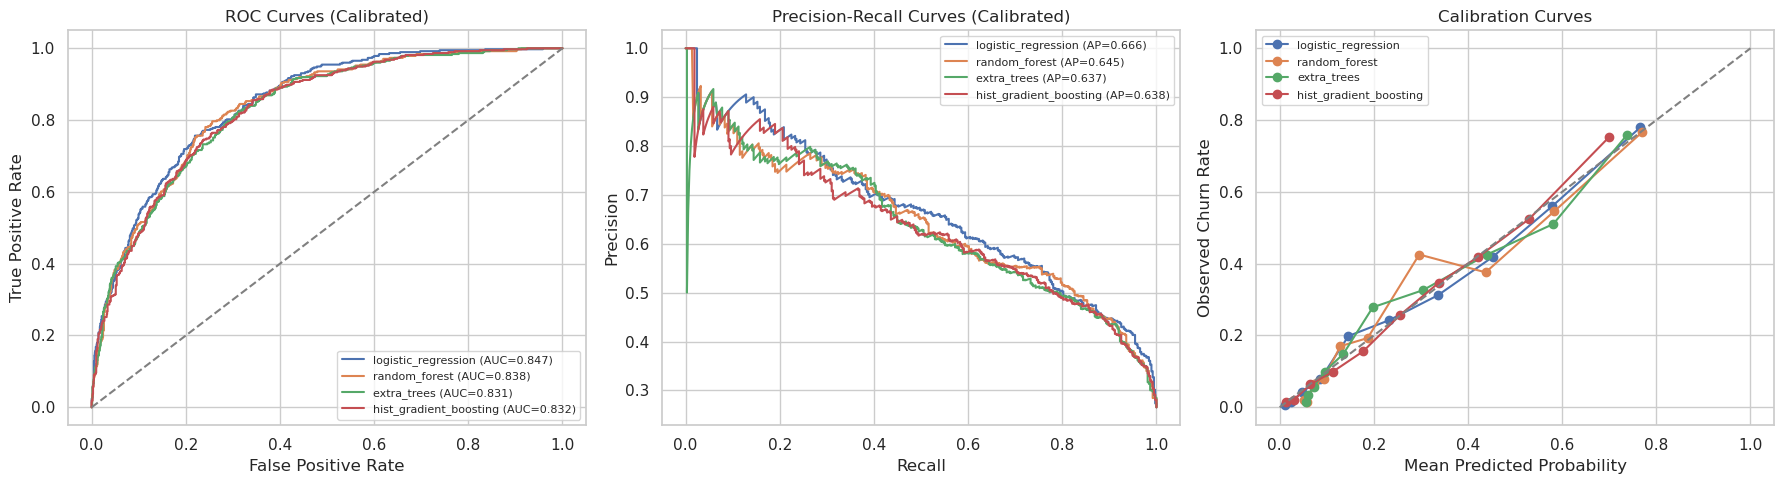

In [40]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
for r in results:
    fpr, tpr, _ = roc_curve(y_test, r['proba_test_calibrated'])
    plt.plot(fpr, tpr, label=f"{r['model']} (AUC={r['roc_auc_calibrated']:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('ROC Curves (Calibrated)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(fontsize=8)

plt.subplot(1, 3, 2)
for r in results:
    prec, rec, _ = precision_recall_curve(y_test, r['proba_test_calibrated'])
    plt.plot(rec, prec, label=f"{r['model']} (AP={r['pr_auc_calibrated']:.3f})")
plt.title('Precision-Recall Curves (Calibrated)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(fontsize=8)

plt.subplot(1, 3, 3)
for r in results:
    frac_pos, mean_pred = calibration_curve(y_test, r['proba_test_calibrated'], n_bins=10, strategy='quantile')
    plt.plot(mean_pred, frac_pos, marker='o', label=r['model'])
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('Calibration Curves')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Observed Churn Rate')
plt.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 17) Threshold Tuning with Business Metrics

In [41]:
best_model_name = metrics_df.iloc[0]['model']
best_obj = next(r for r in results if r['model'] == best_model_name)

best_probs = best_obj['proba_test_calibrated']
threshold_grid = np.arange(0.10, 0.91, 0.05)

biz_rows = []
for th in threshold_grid:
    row = business_metrics_at_threshold(y_test.values, best_probs, threshold=th)
    row['model'] = best_model_name
    biz_rows.append(row)

biz_df = pd.DataFrame(biz_rows).sort_values('threshold').reset_index(drop=True)
optimal_row = biz_df.loc[biz_df['net_value'].idxmax()]

display(biz_df)
print('Best model:', best_model_name)
print('Optimal threshold by net value:', float(optimal_row['threshold']))
print('Max net value:', float(optimal_row['net_value']))
print('ROI at optimal threshold:', float(optimal_row['roi']))

,threshold,tp,fp,fn,tn,precision,recall,gross_saved_revenue,campaign_cost,net_value,roi,targeted_customers,model
0,0.10,357,518,17,517,0.408000,0.954545,74970.0,21875.0,53095.0,2.427200,875,logistic_regression
1,0.15,339,423,35,612,0.444882,0.906417,71190.0,19050.0,52140.0,2.737008,762,logistic_regression
2,0.20,326,364,48,671,0.472464,0.871658,68460.0,17250.0,51210.0,2.968696,690,logistic_regression
3,0.25,301,310,73,725,0.492635,0.804813,63210.0,15275.0,47935.0,3.138134,611,logistic_regression
4,0.30,288,248,86,787,0.537313,0.770053,60480.0,13400.0,47080.0,3.513433,536,logistic_regression
5,0.35,269,203,105,832,0.569915,0.719251,56490.0,11800.0,44690.0,3.787288,472,logistic_regression
6,0.40,248,171,126,864,0.591885,0.663102,52080.0,10475.0,41605.0,3.971838,419,logistic_regression
7,0.45,220,133,154,902,0.623229,0.588235,46200.0,8825.0,37375.0,4.235127,353,logistic_regression
8,0.50,193,98,181,937,0.663230,0.516043,40530.0,7275.0,33255.0,4.571134,291,logistic_regression
9,0.55,165,74,209,961,0.690377,0.441176,34650.0,5975.0,28675.0,4.799163,239,logistic_regression


Best model: logistic_regression
Optimal threshold by net value: 0.1
Max net value: 53095.0
ROI at optimal threshold: 2.4272


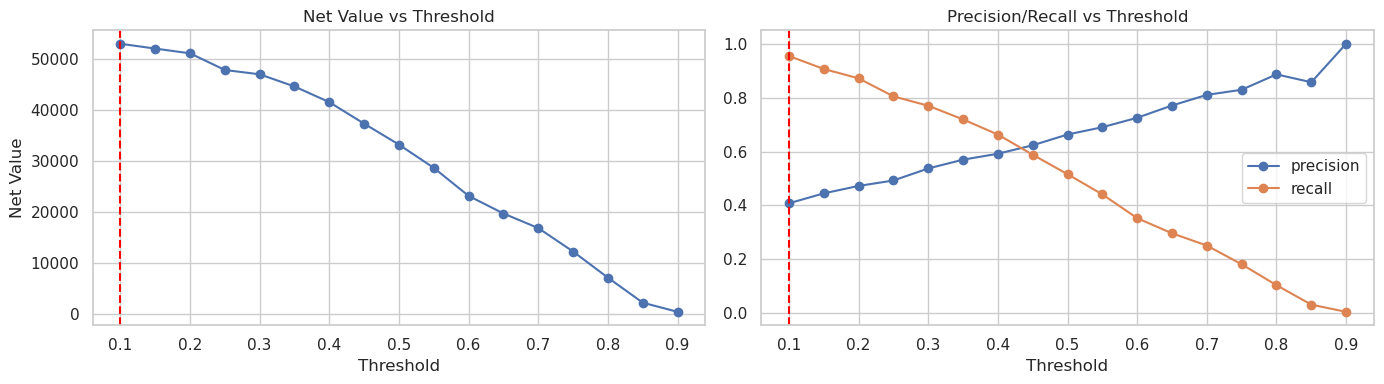

In [42]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

ax[0].plot(biz_df['threshold'], biz_df['net_value'], marker='o')
ax[0].axvline(optimal_row['threshold'], linestyle='--', color='red')
ax[0].set_title('Net Value vs Threshold')
ax[0].set_xlabel('Threshold')
ax[0].set_ylabel('Net Value')

ax[1].plot(biz_df['threshold'], biz_df['precision'], marker='o', label='precision')
ax[1].plot(biz_df['threshold'], biz_df['recall'], marker='o', label='recall')
ax[1].axvline(optimal_row['threshold'], linestyle='--', color='red')
ax[1].set_title('Precision/Recall vs Threshold')
ax[1].set_xlabel('Threshold')
ax[1].legend()

plt.tight_layout()
plt.show()

## 18) Top Drivers -> Retention Strategy Experiments

In [43]:
best_pipeline = best_obj['pipeline']

perm = permutation_importance(
    best_pipeline,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring='average_precision',
    n_jobs=-1,
)

# Important: permutation_importance on a full pipeline reports importances
# for the raw input columns (X_test), not one-hot-expanded transformed features.
feature_names = X_test.columns.tolist()
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std,
}).sort_values('importance_mean', ascending=False)

TOP_N = 15
top_drivers = importance_df.head(TOP_N).copy()
display(top_drivers)

,feature,importance_mean,importance_std
30,total_charges_log1p,0.199687,0.016962
7,InternetService,0.074556,0.014545
24,avg_monthly_spend_proxy,0.066650,0.014583
17,MonthlyCharges,0.052596,0.010800
20,is_monthly,0.041422,0.004490
18,TotalCharges,0.039258,0.007164
14,Contract,0.017672,0.007179
29,monthly_charges_log1p,0.014379,0.004771
22,num_services,0.008694,0.004672
8,OnlineSecurity,0.008177,0.002909


In [44]:
def driver_to_hypothesis(feature_name):
    f = feature_name.lower()
    if 'contract' in f or 'is_monthly' in f:
        return 'Longer commitment nudges reduce churn for at-risk monthly users.'
    if 'internetservice' in f or 'techsupport' in f or 'onlinesecurity' in f:
        return 'Service-quality + support bundles reduce perceived risk and churn intent.'
    if 'paymentmethod' in f or 'electronic' in f:
        return 'Payment-friction interventions reduce involuntary/intentional churn.'
    if 'monthlycharges' in f or 'totalcharges' in f:
        return 'Price-plan optimization reduces value-for-money churn.'
    if 'tenure' in f:
        return 'Lifecycle messaging in early tenure reduces first-year churn.'
    return 'Targeted retention treatment on this driver segment reduces churn.'

experiment_rows = []
for i, row in top_drivers.reset_index(drop=True).iterrows():
    feat = row['feature']
    experiment_rows.append({
        'priority': i + 1,
        'driver_feature': feat,
        'hypothesis': driver_to_hypothesis(feat),
        'experiment_design': 'A/B test: treatment retention offer vs control',
        'primary_kpi': 'Incremental churn reduction',
        'secondary_kpi': 'Incremental net revenue',
        'target_population_rule': f'High-risk customers with elevated value in {feat}',
        'success_criteria': 'Positive incremental net value with p<0.05 on churn delta',
    })

retention_experiments_df = pd.DataFrame(experiment_rows)
display(retention_experiments_df)

,priority,driver_feature,hypothesis,experiment_design,primary_kpi,secondary_kpi,target_population_rule,success_criteria
0,1,total_charges_log1p,Targeted retention treatment on this driver se...,A/B test: treatment retention offer vs control,Incremental churn reduction,Incremental net revenue,High-risk customers with elevated value in tot...,Positive incremental net value with p<0.05 on ...
1,2,InternetService,Service-quality + support bundles reduce perce...,A/B test: treatment retention offer vs control,Incremental churn reduction,Incremental net revenue,High-risk customers with elevated value in Int...,Positive incremental net value with p<0.05 on ...
2,3,avg_monthly_spend_proxy,Targeted retention treatment on this driver se...,A/B test: treatment retention offer vs control,Incremental churn reduction,Incremental net revenue,High-risk customers with elevated value in avg...,Positive incremental net value with p<0.05 on ...
3,4,MonthlyCharges,Price-plan optimization reduces value-for-mone...,A/B test: treatment retention offer vs control,Incremental churn reduction,Incremental net revenue,High-risk customers with elevated value in Mon...,Positive incremental net value with p<0.05 on ...
4,5,is_monthly,Longer commitment nudges reduce churn for at-r...,A/B test: treatment retention offer vs control,Incremental churn reduction,Incremental net revenue,High-risk customers with elevated value in is_...,Positive incremental net value with p<0.05 on ...
5,6,TotalCharges,Price-plan optimization reduces value-for-mone...,A/B test: treatment retention offer vs control,Incremental churn reduction,Incremental net revenue,High-risk customers with elevated value in Tot...,Positive incremental net value with p<0.05 on ...
6,7,Contract,Longer commitment nudges reduce churn for at-r...,A/B test: treatment retention offer vs control,Incremental churn reduction,Incremental net revenue,High-risk customers with elevated value in Con...,Positive incremental net value with p<0.05 on ...
7,8,monthly_charges_log1p,Targeted retention treatment on this driver se...,A/B test: treatment retention offer vs control,Incremental churn reduction,Incremental net revenue,High-risk customers with elevated value in mon...,Positive incremental net value with p<0.05 on ...
8,9,num_services,Targeted retention treatment on this driver se...,A/B test: treatment retention offer vs control,Incremental churn reduction,Incremental net revenue,High-risk customers with elevated value in num...,Positive incremental net value with p<0.05 on ...
9,10,OnlineSecurity,Service-quality + support bundles reduce perce...,A/B test: treatment retention offer vs control,Incremental churn reduction,Incremental net revenue,High-risk customers with elevated value in Onl...,Positive incremental net value with p<0.05 on ...


## 19) Executive Readout Template

Use the tables above to present:
1. Best calibrated model and expected quality (ROC-AUC, PR-AUC, Brier).
2. Chosen operating threshold and expected financial impact.
3. Top driver-led retention experiments prioritized by likely impact and feasibility.

## 20) Production-Readiness v2: Robustness, Uncertainty, and Targeting Policy

This section upgrades the modeling workflow for deployment decisions:

1. Uncertainty intervals from repeated stratified CV.
2. Temporal robustness check (real date-based if available, lifecycle proxy otherwise).
3. Uplift-aware constrained targeting policy simulation.

In [45]:
# 20.1 Champion model + uncertainty intervals (repeated stratified CV)
from sklearn.base import clone
from sklearn.model_selection import RepeatedStratifiedKFold

if 'metrics_df' not in globals() or metrics_df.empty:
    raise ValueError('metrics_df is missing. Run model training section first.')

champion_name = metrics_df.iloc[0]['model']
champion_estimator = models[champion_name]

rkf = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=RANDOM_STATE)

cv_rows = []
for fold_id, (tr_idx, va_idx) in enumerate(rkf.split(X, y), start=1):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

    pipe = Pipeline([
        ('prep', preprocessor),
        ('model', clone(champion_estimator)),
    ])
    pipe.fit(X_tr, y_tr)

    p_raw = pipe.predict_proba(X_va)[:, 1]
    cv_rows.append({
        'fold': fold_id,
        'type': 'raw',
        'roc_auc': roc_auc_score(y_va, p_raw),
        'pr_auc': average_precision_score(y_va, p_raw),
        'brier': brier_score_loss(y_va, p_raw),
    })

    cal = CalibratedClassifierCV(pipe, method='sigmoid', cv=3)
    cal.fit(X_tr, y_tr)
    p_cal = cal.predict_proba(X_va)[:, 1]
    cv_rows.append({
        'fold': fold_id,
        'type': 'calibrated',
        'roc_auc': roc_auc_score(y_va, p_cal),
        'pr_auc': average_precision_score(y_va, p_cal),
        'brier': brier_score_loss(y_va, p_cal),
    })

cv_metrics = pd.DataFrame(cv_rows)

def metric_ci(series):
    return pd.Series({
        'mean': series.mean(),
        'std': series.std(ddof=1),
        'ci95_low': series.quantile(0.025),
        'ci95_high': series.quantile(0.975),
    })

cv_summary = (
    cv_metrics
    .groupby('type')[['roc_auc', 'pr_auc', 'brier']]
    .apply(lambda df: pd.concat({m: metric_ci(df[m]) for m in df.columns}, axis=1))
)

print('Champion model:', champion_name)
display(cv_summary)


Champion model: logistic_regression


roc_auc    pr_auc     brier
type                                              
calibrated mean       0.848913  0.669055  0.133560
           std        0.009744  0.014390  0.003564
           ci95_low   0.829197  0.640900  0.129144
           ci95_high  0.861443  0.692468  0.140888
raw        mean       0.848852  0.668708  0.162332
           std        0.009795  0.014300  0.003937
           ci95_low   0.829139  0.640803  0.156089
           ci95_high  0.861498  0.692204  0.168250

In [46]:
# 20.2 Temporal robustness check (date-based if available, otherwise lifecycle proxy)
DATE_CANDIDATES = ['snapshot_date', 'as_of_date', 'event_date', 'report_date', 'date']
found_date_col = next((c for c in DATE_CANDIDATES if c in modeling_df.columns), None)

robustness_rows = []

if found_date_col is not None:
    tmp = modeling_df.copy()
    tmp[found_date_col] = pd.to_datetime(tmp[found_date_col], errors='coerce')
    tmp = tmp.dropna(subset=[found_date_col]).sort_values(found_date_col)

    cutoff_idx = int(len(tmp) * 0.8)
    train_part = tmp.iloc[:cutoff_idx].copy()
    test_part = tmp.iloc[cutoff_idx:].copy()

    y_tr = train_part['Churn'].map({'Yes': 1, 'No': 0}).astype(int)
    X_tr = train_part.drop(columns=['Churn'])
    y_te = test_part['Churn'].map({'Yes': 1, 'No': 0}).astype(int)
    X_te = test_part.drop(columns=['Churn'])

    temporal_pipe = Pipeline([
        ('prep', preprocessor),
        ('model', clone(champion_estimator)),
    ])
    temporal_pipe.fit(X_tr, y_tr)
    p_te = temporal_pipe.predict_proba(X_te)[:, 1]

    robustness_rows.append({
        'scheme': 'date_based_oot',
        'train_rows': len(X_tr),
        'test_rows': len(X_te),
        'roc_auc': roc_auc_score(y_te, p_te),
        'pr_auc': average_precision_score(y_te, p_te),
        'brier': brier_score_loss(y_te, p_te),
        'note': f'column={found_date_col}'
    })
else:
    # No event/snapshot date available -> lifecycle proxy using tenure cohorts
    if 'tenure' not in modeling_df.columns:
        raise ValueError('No date column and no tenure column found for robustness proxy check.')

    tmp = modeling_df.copy()
    q1, q3 = tmp['tenure'].quantile([0.25, 0.75]).values

    cohorts = {
        'early_lifecycle': tmp[tmp['tenure'] <= q1],
        'late_lifecycle': tmp[tmp['tenure'] >= q3],
    }

    base_pipe = Pipeline([
        ('prep', preprocessor),
        ('model', clone(champion_estimator)),
    ])
    base_pipe.fit(X_train, y_train)

    for cohort_name, dfc in cohorts.items():
        yc = dfc['Churn'].map({'Yes': 1, 'No': 0}).astype(int)
        Xc = dfc.drop(columns=['Churn'])
        pc = base_pipe.predict_proba(Xc)[:, 1]
        robustness_rows.append({
            'scheme': 'lifecycle_proxy',
            'cohort': cohort_name,
            'rows': len(Xc),
            'roc_auc': roc_auc_score(yc, pc),
            'pr_auc': average_precision_score(yc, pc),
            'brier': brier_score_loss(yc, pc),
            'note': 'No date column; proxy by tenure quartiles'
        })

robustness_df = pd.DataFrame(robustness_rows)
display(robustness_df)


,scheme,cohort,rows,roc_auc,pr_auc,brier,note
0,lifecycle_proxy,early_lifecycle,1854,0.787419,0.774404,0.223722,No date column; proxy by tenure quartiles
1,lifecycle_proxy,late_lifecycle,1819,0.817274,0.284693,0.082386,No date column; proxy by tenure quartiles


In [47]:
# 20.3 Uplift-aware constrained targeting simulation (policy layer)
# Segment assumptions should be replaced with real campaign experiment estimates.
POLICY_BUDGET = 18000.0
MAX_CONTACT_RATE = 0.35   # at most 35% of scored base

# Use best calibrated model from previous section
if 'best_obj' not in globals():
    raise ValueError('best_obj missing. Run threshold/business section first.')

scored = X_test.copy()
scored = scored.reset_index(drop=True)
scored['y_true'] = y_test.reset_index(drop=True)
scored['p_churn'] = best_obj['proba_test_calibrated']

# Segment by monthly charges as ARPU proxy
if 'MonthlyCharges' in scored.columns:
    scored['arpu_segment'] = pd.qcut(scored['MonthlyCharges'], q=3, labels=['low', 'mid', 'high'])
    arpu_map = {'low': float(scored.loc[scored['arpu_segment']=='low', 'MonthlyCharges'].mean()),
                'mid': float(scored.loc[scored['arpu_segment']=='mid', 'MonthlyCharges'].mean()),
                'high': float(scored.loc[scored['arpu_segment']=='high', 'MonthlyCharges'].mean())}
else:
    scored['arpu_segment'] = 'mid'
    arpu_map = {'low': ARPU * 0.8, 'mid': ARPU, 'high': ARPU * 1.25}

# Illustrative segment-specific uplift/cost assumptions
uplift_map = {'low': 0.18, 'mid': 0.24, 'high': 0.30}
cost_map = {'low': 18.0, 'mid': 24.0, 'high': 32.0}

scored['seg_uplift'] = scored['arpu_segment'].map(uplift_map).astype(float)
scored['seg_cost'] = scored['arpu_segment'].map(cost_map).astype(float)
scored['seg_arpu'] = scored['arpu_segment'].map(arpu_map).astype(float)

# Optional compliance flag if present in data
if 'DoNotContact' in scored.columns:
    scored['contactable'] = (scored['DoNotContact'].astype(str).str.lower() != 'yes').astype(int)
else:
    scored['contactable'] = 1

scored['expected_gross'] = scored['p_churn'] * scored['seg_uplift'] * scored['seg_arpu'] * RETENTION_MONTHS
scored['expected_net'] = scored['expected_gross'] - scored['seg_cost']

candidate = scored[(scored['contactable'] == 1) & (scored['expected_net'] > 0)].copy()
candidate = candidate.sort_values('expected_net', ascending=False).reset_index(drop=True)

max_contacts = int(len(scored) * MAX_CONTACT_RATE)
candidate['cum_cost'] = candidate['seg_cost'].cumsum()
selected = candidate[(candidate.index < max_contacts) & (candidate['cum_cost'] <= POLICY_BUDGET)].copy()

policy_summary = pd.DataFrame([
    {
        'population_scored': len(scored),
        'eligible_positive_npv': len(candidate),
        'selected_contacts': len(selected),
        'contact_rate_selected': len(selected) / max(len(scored), 1),
        'budget_used': float(selected['seg_cost'].sum()),
        'expected_gross_saved': float(selected['expected_gross'].sum()),
        'expected_net_value': float(selected['expected_net'].sum()),
        'expected_roi': float(selected['expected_net'].sum() / max(selected['seg_cost'].sum(), 1e-9)),
    }
])

display(policy_summary)

display(
    selected[['p_churn', 'arpu_segment', 'seg_uplift', 'seg_cost', 'expected_net']]
    .groupby('arpu_segment')
    .agg(selected_n=('p_churn', 'count'),
         mean_p_churn=('p_churn', 'mean'),
         avg_expected_net=('expected_net', 'mean'))
    .reset_index()
)


,population_scored,eligible_positive_npv,selected_contacts,contact_rate_selected,budget_used,expected_gross_saved,expected_net_value,expected_roi
0,1409,762,493,0.349894,14176.0,73059.147581,58883.147581,4.153721


,arpu_segment,selected_n,mean_p_churn,avg_expected_net
0,mid,200,0.587119,91.187436
1,high,293,0.491020,138.722390


In [48]:
# 20.4 Deployment checklist snapshot
readiness_checks = {
    'champion_selected': 'champion_name' in globals(),
    'cv_uncertainty_ready': 'cv_summary' in globals(),
    'robustness_check_ready': 'robustness_df' in globals(),
    'policy_simulation_ready': 'policy_summary' in globals(),
    'calibrated_scoring_available': 'best_obj' in globals(),
}

readiness_df = pd.DataFrame.from_dict(readiness_checks, orient='index', columns=['status'])
display(readiness_df)
print('Production-readiness gate pass:', bool(readiness_df['status'].all()))


,status
champion_selected,True
cv_uncertainty_ready,True
robustness_check_ready,True
policy_simulation_ready,True
calibrated_scoring_available,True


Production-readiness gate pass: True


## 21) Phase 1 Export for API Deployment

This cell exports the champion calibrated pipeline and deployment metadata from this notebook run.
It creates `artifacts/churn_model.joblib`, `artifacts/metadata.json`, and `artifacts/leaderboard.json`.


In [52]:
from pathlib import Path
import json
import joblib

# Guardrails: require notebook training/evaluation cells to be executed first.
required_objects = ['best_obj', 'metrics_df', 'optimal_row', 'X_train', 'X_test']
missing = [name for name in required_objects if name not in globals()]
if missing:
    raise ValueError(f"Missing required notebook objects: {missing}. Run training/model-selection cells first.")

# Resolve project root regardless of whether notebook is started from repo root or notebooks/.
cwd = Path.cwd().resolve()
project_root = None
for candidate in [cwd, *cwd.parents]:
    if (candidate / 'data' / 'telco_churn.csv').exists():
        project_root = candidate
        break
if project_root is None:
    raise FileNotFoundError("Could not locate project root containing data/telco_churn.csv")

artifacts_dir = project_root / 'artifacts'
artifacts_dir.mkdir(parents=True, exist_ok=True)

model_path = artifacts_dir / 'churn_model.joblib'
metadata_path = artifacts_dir / 'metadata.json'
leaderboard_path = artifacts_dir / 'leaderboard.json'
sample_payload_path = artifacts_dir / 'sample_payload.json'

champion_name = str(metrics_df.iloc[0]['model'])
champion_pipeline = best_obj['pipeline']
serving_threshold = float(optimal_row['threshold'])

# Feature contract for API payloads
feature_columns = X_train.columns.tolist()
numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_features = [c for c in feature_columns if c not in numeric_features]

# Persist model artifact
joblib.dump(champion_pipeline, model_path)

# Persist leaderboard sorted by your notebook ranking
leaderboard_df = metrics_df.copy()
print(metrics_df.columns.tolist())
leaderboard_df = leaderboard_df.sort_values(by=['f1', 'roc_auc', 'average_precision'], ascending=False)
leaderboard_records = leaderboard_df.to_dict(orient='records')
with leaderboard_path.open('w', encoding='utf-8') as f:
    json.dump(leaderboard_records, f, indent=2)

# Persist deployment metadata
metadata_payload = {
    'source_notebook': 'notebooks/telco_churn_ordered_sota_modeling.ipynb',
    'model_name': champion_name,
    'artifact': model_path.name,
    'target': 'Churn',
    'class_mapping': {'No': 0, 'Yes': 1},
    'positive_class': 'Yes',
    'threshold': serving_threshold,
    'feature_columns': feature_columns,
    'numeric_features': numeric_features,
    'categorical_features': categorical_features,
    'evaluation': {
        'model_ranking_top': leaderboard_records[0] if leaderboard_records else None,
        'optimal_business_row': {
            k: (float(v) if hasattr(v, 'item') else v)
            for k, v in optimal_row.to_dict().items()
        }
    }
}
with metadata_path.open('w', encoding='utf-8') as f:
    json.dump(metadata_payload, f, indent=2)

# Persist one request example for future FastAPI /predict payload testing
sample_payload = X_test.head(1).to_dict(orient='records')[0]
with sample_payload_path.open('w', encoding='utf-8') as f:
    json.dump(sample_payload, f, indent=2)

phase1_export_summary = {
    'model_path': str(model_path),
    'metadata_path': str(metadata_path),
    'leaderboard_path': str(leaderboard_path),
    'sample_payload_path': str(sample_payload_path),
    'champion_model': champion_name,
    'threshold': serving_threshold,
}
print('Phase 1 export complete:')
print(json.dumps(phase1_export_summary, indent=2))



['model', 'roc_auc_raw', 'pr_auc_raw', 'brier_raw', 'roc_auc_calibrated', 'pr_auc_calibrated', 'brier_calibrated']


KeyError: 'f1'